# Travel Reimbursement Approval Agent
**Candidate:** Satyanarayan Sharma · **Assignment:** AI Developer — GenAI / Agentic AI

A tool-calling LLM agent that reviews travel reimbursement claims against the policy in Appendix A. For each claim it returns a structured, policy-cited recommendation: `APPROVE`, `PARTIAL_APPROVE`, `REJECT` or `MANUAL_REVIEW`.

**Contents:**
1. Setup & configuration
2. Policy knowledge base & retrieval
3. Claim intake
4. Tools
5. Policy guardrail
6. Agent loop
7. Run on all claims
8. Sample outputs
9. Audit trail
10. Evaluation & tests

After section 10: Dashboard & review console → Design Notes & Reasoning → Final structured results.

## README

### How it works
```
Claim (JSON / form)
  → intake validation + normalisation
  → LLM agent loop (the LLM chooses which tools to call)
       tools: search_policy · check_category_eligibility · check_receipts
              check_per_diem_limits · check_submission_timeliness · check_approval_threshold
  → submit_decision (validated; errors go back to the LLM so it can self-correct)
  → policy guardrail (the LLM can escalate to MANUAL_REVIEW but can never downgrade one)
  → result JSON + audit trail → dashboard / review console
```

### Setup
1. Python 3.10+ and Jupyter.
2. The first code cell installs any missing packages (`openai`, `matplotlib`, `pandas`, `ipywidgets`, `python-dotenv`).
3. **Optional, for LLM mode:** get a free API key. The default is Groq (console.groq.com, no card needed). Gemini's free tier or a local Ollama model also work.

### Environment variables
| Variable | Needed | Default | Purpose |
|---|---|---|---|
| `LLM_PROVIDER` | no | `groq` | `groq` · `gemini` · `ollama` · `openai` |
| `LLM_API_KEY` | for LLM mode | – | API key. `GROQ_API_KEY`, `GEMINI_API_KEY` and `OPENAI_API_KEY` are also read |
| `LLM_MODEL` | no | provider default | Model override (it must support tool calling) |
| `LLM_BASE_URL` | no | provider default | Any OpenAI-compatible endpoint |
| `AGENT_MODE` | no | `auto` | `auto` uses the LLM when one is configured, otherwise rules · `llm` · `rules` |
| `LLM_PAUSE_SECONDS` | no | `8` on Groq | Pause between claims, to stay within free-tier token-per-minute limits |

You can also put these in a `.env` file next to the notebook.

```bash
export GROQ_API_KEY="gsk_..."          # Windows PowerShell: $env:GROQ_API_KEY="gsk_..."
jupyter notebook satyanarayansharma.ipynb
```

### Run
Use **Kernel → Restart & Run All**; no manual steps are needed. Without a key, the notebook runs in deterministic **rules** mode, so it never breaks. With a key, the LLM chooses the tools, reconciles their findings and writes the explanations. Every result records which path produced it.

### Output schema (one object per claim)
| Field | Type | Meaning |
|---|---|---|
| `claim_id` | string | Claim identifier from the input |
| `decision` | enum | `APPROVE` · `PARTIAL_APPROVE` · `REJECT` · `MANUAL_REVIEW` |
| `approved_amount` | float | USD the agent approves. Always 0 for `REJECT` and `MANUAL_REVIEW` (the agent has no authority) |
| `deducted_amount` | float | USD removed: cap excess plus ineligible items. For `MANUAL_REVIEW`, only certain (POL-CAT-02) deductions |
| `missing_docs` | list[str] | Documents a reviewer must obtain |
| `policy_refs` | list[str] | `POL-*` rules evaluated for this claim, in policy order |
| `confidence` | float 0–1 | Computed confidence that the routing is correct (not self-reported by the LLM) |
| `explanation` | string | Plain-language reason. Manual-review explanations start with `[REASON_CODES]` |
| `tools_used` | list[str] | Tools called by the agent, in order; `submit_decision` is always last |

### Manual-review reason codes
| Code | Severity | Rule | Raised when |
|---|---|---|---|
| `RECEIPT_MISSING` | hard | POL-RCT-02 | A line over \$25, or any airfare/lodging line, has no receipt |
| `AIRFARE_CLASS_EXCEPTION` | hard | POL-AIR-01 | The fare is business, first or premium class |
| `DIRECTOR_TIER` | hard | POL-APR-03 | The reimbursable total is over \$2,000 |
| `LATE_SUBMISSION` | hard | POL-TIME-01 | The claim was submitted more than 30 days after the expense date |
| `DATES_CONFLICT` | soft | POL-PD-0x | More nights or days are claimed than the trip dates allow |
| `GROUP_OR_CLIENT_MEAL` | soft | POL-PD-01 | A hosted or group meal, which the per-diem does not clearly cover |
| `AIRFARE_CLASS_UNSTATED` | soft | POL-AIR-01 | The airfare line does not name a cabin class |
| `INELIGIBLE_TERM` | soft | POL-CAT-02 | An eligible line's description mentions alcohol, spa, gifts, fines, etc. |
| `UNKNOWN_CATEGORY` | soft | POL-CAT-01 | The category is in neither the eligible nor the ineligible list |
| `BUSINESS_PURPOSE_UNCLEAR` | soft | POL-CAT-01 | The trip purpose states no business reason |
| `SUBMITTED_BEFORE_TRIP_END` | soft | POL-TIME-01 | The submission date is before the trip ended |
| `DATA_QUALITY` | soft | POL-CAT-01 | Intake problems, e.g. the stated total doesn't match the line items |
| `AGENT_ESCALATION` | – | – | The LLM escalated an ambiguity the tools did not flag |

*Hard* flags are required by policy. *Soft* flags mark ambiguity; each one lowers confidence by 0.05.

### Key design choices
- **The LLM orchestrates and explains; deterministic tools do the arithmetic and hard rules.** Money math and cap checks are never left to the model.
- **Structured output goes through a validated tool call.** `submit_decision` is checked for the decision enum, known `POL-*` ids, required checks, consistency with tool flags, and dollar figures that actually appear in tool results. Failures are sent back to the LLM (up to 2 retries) before the notebook falls back to rules.
- **Guardrail:** a policy engine recomputes the decision from tool facts. The LLM may *escalate* to `MANUAL_REVIEW` if it gives a reason, but it cannot approve something the rules flag.
- **When uncertain, the claim goes to `MANUAL_REVIEW`,** with reason codes, as the policy's own decision guidance says.
- **Lightweight by design:** direct OpenAI-compatible tool calling (no framework) and in-memory BM25 retrieval (no vector database).

## 1. Setup & configuration

In [1]:
# Install missing packages (skipped for anything already installed)
import importlib, importlib.util, os, subprocess, sys

PACKAGES = {                      # import name -> pip spec
    "openai": "openai>=1.40",     # only needed for LLM mode
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "ipywidgets": "ipywidgets",   # interactive review console (optional)
    "dotenv": "python-dotenv",    # optional .env support
}
missing = [spec for mod, spec in PACKAGES.items() if importlib.util.find_spec(mod) is None]
if missing and os.getenv("SKIP_PIP_INSTALL") != "1":
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", *missing], check=False)
    importlib.invalidate_caches()
still_missing = [spec for mod, spec in PACKAGES.items() if importlib.util.find_spec(mod) is None]
print("Dependencies OK" if not still_missing else f"Not installed (notebook degrades gracefully): {still_missing}")

Dependencies OK


In [2]:
import json, math, re, time
from datetime import date, datetime

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

try:
    from dotenv import load_dotenv
    load_dotenv()                 # optional: read a local .env file
except ImportError:
    pass

# Any OpenAI-compatible endpoint works. These are free or local defaults.
PROVIDERS = {
    "groq":   {"base_url": "https://api.groq.com/openai/v1", "model": "llama-3.3-70b-versatile", "key_env": "GROQ_API_KEY"},
    "gemini": {"base_url": "https://generativelanguage.googleapis.com/v1beta/openai/", "model": "gemini-2.5-flash", "key_env": "GEMINI_API_KEY"},
    "ollama": {"base_url": "http://localhost:11434/v1", "model": "qwen2.5:7b-instruct", "key_env": None},
    "openai": {"base_url": None, "model": "gpt-4.1-mini", "key_env": "OPENAI_API_KEY"},
}
# `or` (not getenv defaults) so that empty values in a .env file fall back to defaults
LLM_PROVIDER = (os.getenv("LLM_PROVIDER") or "groq").lower()
_prov = PROVIDERS.get(LLM_PROVIDER, PROVIDERS["groq"])
LLM_MODEL = os.getenv("LLM_MODEL") or _prov["model"]
LLM_BASE_URL = os.getenv("LLM_BASE_URL") or _prov["base_url"]
LLM_API_KEY = (os.getenv("LLM_API_KEY")
               or (os.getenv(_prov["key_env"]) if _prov["key_env"] else None)
               or ("ollama" if LLM_PROVIDER == "ollama" else None))
AGENT_MODE = (os.getenv("AGENT_MODE") or "auto").lower()
LLM_PAUSE_S = float(os.getenv("LLM_PAUSE_SECONDS") or ("8" if LLM_PROVIDER == "groq" else "0"))


def build_llm_client():
    """Return (client, reason). The client is None when LLM mode is disabled or unavailable."""
    if AGENT_MODE == "rules":
        return None, "AGENT_MODE=rules"
    if not LLM_API_KEY:
        return None, "no API key configured"
    try:
        from openai import OpenAI
    except ImportError:
        return None, "openai package not installed"
    # The SDK retries 429s/5xx and honours retry-after headers
    return OpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL, max_retries=3, timeout=60), "ok"


LLM_CLIENT, _why = build_llm_client()
if AGENT_MODE == "llm" and LLM_CLIENT is None:
    raise RuntimeError(f"AGENT_MODE=llm but no LLM is available: {_why}")
RUN_MODE = "llm" if LLM_CLIENT else "rules"
LLM_DISABLED_REASON = None        # circuit breaker, set on auth/config errors

if RUN_MODE == "llm":
    print(f"Run mode: LLM agent | provider={LLM_PROVIDER} | model={LLM_MODEL}")
else:
    print(f"Run mode: RULES (deterministic fallback) | reason: {_why}")

Run mode: LLM agent | provider=groq | model=llama-3.3-70b-versatile


## 2. Policy knowledge base & retrieval (context grounding)
The Appendix A policy is stored as retrievable rules with stable `POL-*` ids. Alongside it are the machine-readable tables that the tools apply: the limit table, the approval matrix and the category eligibility list. Retrieval uses a small **BM25** index. With 12 short rules, lexical search is exact, deterministic and needs no dependencies; rule ids can also be looked up directly.

In [3]:
POLICY_RULES = [
    {"id": "POL-CAT-01", "title": "Eligible categories",
     "text": "Reimbursable when incurred for a documented business purpose: airfare (economy class only, see POL-AIR-01); "
             "lodging (hotel room charges); meals (subject to per-diem limits, see POL-PD-01); ground transport "
             "(taxi, rideshare, train, rental car, parking); conference / registration fees."},
    {"id": "POL-CAT-02", "title": "Ineligible items",
     "text": "Never reimbursable; rejected (deducted in full): alcohol and minibar charges; spa, gym, and personal "
             "entertainment; in-room movies, personal shopping, gifts; traffic fines, penalties, and late fees; "
             "any personal (non-business) expense."},
    {"id": "POL-PD-01", "title": "Meals per-diem",
     "text": "Meals: maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed."},
    {"id": "POL-PD-02", "title": "Lodging nightly limit",
     "text": "Lodging (hotel): maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed."},
    {"id": "POL-PD-03", "title": "Ground transport daily limit",
     "text": "Ground transport (taxi, rideshare, train, rental car, parking): maximum $50 per day. Amounts above the cap are deducted."},
    {"id": "POL-AIR-01", "title": "Airfare class",
     "text": "Only economy class airfare is reimbursable. Business/first-class fares are a policy exception and must be "
             "routed to Manual Review (not auto-deducted, because a pre-approval may exist)."},
    {"id": "POL-RCT-01", "title": "Receipt required above $25",
     "text": "Any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always "
             "require a receipt regardless of amount."},
    {"id": "POL-RCT-02", "title": "Missing receipt handling",
     "text": "If a receipt is missing for an item that requires one, the item is not silently rejected; the claim is "
             "routed to Manual Review so the reviewer can request the receipt."},
    {"id": "POL-APR-01", "title": "Auto-approve tier",
     "text": "Total reimbursable (after per-diem deductions) <= $500: may be auto-approved by the agent if fully compliant."},
    {"id": "POL-APR-02", "title": "Manager tier",
     "text": "Total reimbursable > $500 and <= $2,000: eligible for approval, treated as approvable when fully compliant."},
    {"id": "POL-APR-03", "title": "Director / Manual-Review tier (high value)",
     "text": "Total reimbursable > $2,000 exceeds the agent's auto-approval authority and must be routed to Manual Review "
             "(director approval required), even if otherwise compliant."},
    {"id": "POL-TIME-01", "title": "Submission window (timeliness, late claims)",
     "text": "Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review."},
    {"id": "GUIDANCE", "title": "Decision guidance (how the rules combine)",
     "text": "Approve: every item eligible, all receipts present, all within per-diem, total within an approvable tier. "
             "Partially approve: the claim is valid but some amounts exceed per-diem caps; reimburse up to the cap and "
             "deduct the excess. Reject: the claimed items are ineligible with nothing reimbursable. Manual review: any "
             "ambiguity, policy exception, high value, missing required receipt, or conflicting information. Prefer "
             "manual review over forcing a decision."},
]
POLICY_IDS = [r["id"] for r in POLICY_RULES if r["id"].startswith("POL-")]
POLICY_ORDER = {rid: i for i, rid in enumerate(POLICY_IDS)}

# Machine-readable tables (the "limit table / approval matrix / category eligibility file")
LIMIT_TABLE = {
    "meals":            {"cap": 75.0,  "unit": "day",   "rule": "POL-PD-01"},
    "lodging":          {"cap": 200.0, "unit": "night", "rule": "POL-PD-02"},
    "ground_transport": {"cap": 50.0,  "unit": "day",   "rule": "POL-PD-03"},
}
APPROVAL_MATRIX = [
    {"max_total": 500.0,    "rule": "POL-APR-01", "tier": "auto-approve", "agent_can_approve": True},
    {"max_total": 2000.0,   "rule": "POL-APR-02", "tier": "manager",      "agent_can_approve": True},
    {"max_total": math.inf, "rule": "POL-APR-03", "tier": "director",     "agent_can_approve": False},
]
CATEGORY_ELIGIBILITY = {
    "eligible": {"airfare", "lodging", "meals", "ground_transport", "conference_fees"},
    "ineligible": {"alcohol", "minibar", "spa", "gym", "entertainment", "personal_entertainment", "in_room_movies",
                   "movies", "shopping", "personal_shopping", "gift", "gifts", "traffic_fine", "fines", "penalty",
                   "penalties", "late_fee", "late_fees", "personal"},
    "aliases": {"taxi": "ground_transport", "rideshare": "ground_transport", "train": "ground_transport",
                "rental_car": "ground_transport", "parking": "ground_transport", "hotel": "lodging",
                "flight": "airfare", "conference": "conference_fees", "registration": "conference_fees"},
}
RECEIPT_RULES = {"threshold": 25.0, "always_required": {"airfare", "lodging"}}
SUBMISSION_WINDOW_DAYS = 30

# Heuristic patterns used to raise *ambiguity* flags (these route to manual review, never auto-deduct)
BUSINESS_PURPOSE_PATTERN = r"\b(business|client|customer|conference|vendor|meeting|site visit|negotiation|training|summit)\b"
INELIGIBLE_TERMS_PATTERN = (r"\b(alcohol|wine|beer|liquor|bar tab|minibar|spa|gym|massage|movies?|gifts?|souvenirs?|"
                            r"traffic fine|parking (?:fine|ticket)|speeding|penalt(?:y|ies)|late fees?)\b")
GROUP_MEAL_PATTERN = r"\b(for \d+|clients?|customers?|team|guests?|group)\b"


class PolicyRetriever:
    """Minimal in-memory BM25 index over policy rules.

    `search(query, top_k)` returns rule dicts ranked by BM25 score. Any exact `POL-*` ids in the
    query are always returned first, so the agent can fetch a specific rule by id.
    """

    def __init__(self, docs, k1=1.5, b=0.75):
        self.docs, self.k1, self.b = docs, k1, b
        self.toks = [self._tok(f"{d['id']} {d['title']} {d['text']}") for d in docs]
        self.avgdl = sum(map(len, self.toks)) / len(self.toks)
        self.df = {}
        for toks in self.toks:
            for t in set(toks):
                self.df[t] = self.df.get(t, 0) + 1

    @staticmethod
    def _tok(text):
        return re.findall(r"[a-z0-9]+", text.lower())

    def search(self, query, top_k=3):
        wanted = set(re.findall(r"POL-[A-Z]+-\d+", query.upper()))
        exact = [d for d in self.docs if d["id"] in wanted]
        n, scored = len(self.docs), []
        for d, toks in zip(self.docs, self.toks):
            tf, score = {}, 0.0
            for t in toks:
                tf[t] = tf.get(t, 0) + 1
            for t in set(self._tok(query)):
                if t in tf:
                    idf = math.log(1 + (n - self.df[t] + 0.5) / (self.df[t] + 0.5))
                    score += idf * tf[t] * (self.k1 + 1) / (tf[t] + self.k1 * (1 - self.b + self.b * len(toks) / self.avgdl))
            if score > 0 and d not in exact:
                scored.append((score, d))
        ranked = exact + [d for _, d in sorted(scored, key=lambda x: -x[0])]
        return ranked[:max(int(top_k), len(exact))]


RETRIEVER = PolicyRetriever(POLICY_RULES)
for q in ["hotel per night limit", "missing receipt", "business class flight", "POL-TIME-01"]:
    print(f"{q!r:28} -> {[d['id'] for d in RETRIEVER.search(q, 3)]}")

'hotel per night limit'      -> ['POL-PD-02', 'POL-PD-03', 'POL-CAT-01']
'missing receipt'            -> ['POL-RCT-02', 'POL-RCT-01', 'GUIDANCE']
'business class flight'      -> ['POL-AIR-01', 'POL-CAT-01', 'POL-CAT-02']
'POL-TIME-01'                -> ['POL-TIME-01', 'POL-CAT-01', 'POL-PD-01']


## 3. Claim intake
These are the five claims from Appendix B, entered unchanged as JSON; no other claims are evaluated. `intake_claim()` accepts a dict or a JSON string (from the form in the review console, or an API body). It validates the schema, normalises categories, and reads quantities such as "2 nights" or "3 days" from the descriptions. Data-quality problems do not crash the run; they become manual-review flags.

In [4]:
SAMPLE_CLAIMS = [
    {"claim_id": "CLM-001", "employee": "A. Rivera", "purpose": "Attend 2-day industry conference (business)",
     "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20", "currency": "USD", "total_claimed": 1110.00,
     "items": [
         {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True},
         {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True},
         {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True},
         {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True}]},
    {"claim_id": "CLM-002", "employee": "B. Osei", "purpose": "Weekend hotel stay",
     "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25", "currency": "USD", "total_claimed": 380.00,
     "items": [
         {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True},
         {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True}]},
    {"claim_id": "CLM-003", "employee": "C. Nakamura", "purpose": "Client site visit (business)",
     "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22", "currency": "USD", "total_claimed": 940.00,
     "items": [
         {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True},
         {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True},
         {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True}]},
    {"claim_id": "CLM-004", "employee": "D. Fischer", "purpose": "International vendor negotiation (business)",
     "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28", "currency": "USD", "total_claimed": 3000.00,
     "items": [
         {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": True},
         {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False}]},
    {"claim_id": "CLM-005", "employee": "E. Haddad", "purpose": "Client dinner / business development",
     "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24", "currency": "USD", "total_claimed": 220.00,
     "items": [
         {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": False}]},
]

CLAIM_FIELDS = {"claim_id": str, "employee": str, "purpose": str, "trip_start": str, "trip_end": str, "submitted": str, "items": list}
ITEM_FIELDS = {"category": str, "description": str, "amount": (int, float, str), "receipt_attached": (bool, str)}


class IntakeError(ValueError):
    pass


def _as_bool(v):
    """Accept real booleans or 'Yes'/'No'-style strings (as in the Appendix B tables)."""
    return v if isinstance(v, bool) else str(v).strip().lower() in {"yes", "y", "true", "1"}


def intake_claim(payload):
    """Validate and normalise a raw claim (a dict or JSON string).

    Raises IntakeError for structural problems (missing fields, bad types or dates, non-numeric
    amounts). Softer problems (a mismatched total, non-USD currency, non-positive amounts) are
    recorded in `data_issues` and become DATA_QUALITY review flags instead of crashing the run.
    Adds: trip_days, trip_nights, per-item line number, normalised category, and the
    quantity/quantity_unit parsed from descriptions such as "2 nights" or "3 days".
    """
    if isinstance(payload, str):
        try:
            payload = json.loads(payload)
        except json.JSONDecodeError as exc:
            raise IntakeError(f"invalid JSON: {exc}") from exc
    errors = [f"'{f}' missing or not {t.__name__}" for f, t in CLAIM_FIELDS.items() if not isinstance(payload.get(f), t)]
    if not errors and not payload["items"]:
        errors.append("claim has no line items")
    for i, it in enumerate(payload.get("items") or [], 1):
        errors += [f"item {i}: '{f}' missing/invalid" for f, t in ITEM_FIELDS.items() if not isinstance(it.get(f), t)]
    if errors:
        raise IntakeError("; ".join(errors))

    c, issues = {k: v for k, v in payload.items() if k != "items"}, []
    try:
        c["_start"], c["_end"], c["_submitted"] = (date.fromisoformat(payload[k]) for k in ("trip_start", "trip_end", "submitted"))
    except ValueError as exc:
        raise IntakeError(f"bad date: {exc}") from exc
    if c["_end"] < c["_start"]:
        issues.append("trip_end is before trip_start")
    span = (c["_end"] - c["_start"]).days
    c["trip_days"], c["trip_nights"] = span + 1, max(span, 0)
    c["currency"] = payload.get("currency", "USD")
    if c["currency"] != "USD":
        issues.append(f"currency {c['currency']} is not USD; caps are defined in USD")

    items = []
    for i, raw in enumerate(payload["items"], 1):
        cat = re.sub(r"[\s\-]+", "_", raw["category"].strip().lower())
        try:
            amount = round(float(raw["amount"]), 2)
        except ValueError as exc:
            raise IntakeError(f"item {i}: amount is not a number") from exc
        if not math.isfinite(amount) or amount <= 0:
            issues.append(f"item {i}: non-positive amount {amount}")
        qty = re.search(r"(\d+)\s*(night|day)s?\b", raw["description"], re.I)
        items.append({"line": i, "category": CATEGORY_ELIGIBILITY["aliases"].get(cat, cat),
                      "description": raw["description"].strip(), "amount": amount,
                      "receipt_attached": _as_bool(raw["receipt_attached"]),
                      "quantity": int(qty.group(1)) if qty else None,
                      "quantity_unit": qty.group(2).lower() if qty else None})
    c["items"] = items
    total = round(sum(it["amount"] for it in items), 2)
    if "total_claimed" in payload and abs(float(payload["total_claimed"]) - total) > 0.005:
        issues.append(f"stated total ${float(payload['total_claimed']):,.2f} != sum of items ${total:,.2f}")
    c["total_claimed"], c["data_issues"] = total, issues
    return c


def claim_public(c):
    """JSON-safe view of a normalised claim (drops internal date objects), used in LLM prompts."""
    return {k: v for k, v in c.items() if not k.startswith("_")}


CLAIM_STORE = {}
for raw in SAMPLE_CLAIMS:
    CLAIM_STORE[raw["claim_id"]] = intake_claim(raw)

display(pd.DataFrame([{"claim_id": c["claim_id"], "employee": c["employee"], "line": it["line"], "category": it["category"],
                       "description": it["description"], "amount": it["amount"], "receipt": it["receipt_attached"],
                       "parsed_qty": f"{it['quantity']} {it['quantity_unit']}" if it["quantity"] else "-",
                       "trip": f"{c['trip_start']} to {c['trip_end']}", "submitted": c["submitted"]}
                      for c in CLAIM_STORE.values() for it in c["items"]]))
print("Intake issues:", {cid: c["data_issues"] for cid, c in CLAIM_STORE.items() if c["data_issues"]} or "none")

,claim_id,employee,line,category,description,amount,receipt,parsed_qty,trip,submitted
0,CLM-001,A. Rivera,1,airfare,Round-trip economy airfare,420.0,True,-,2026-06-10 to 2026-06-12,2026-06-20
1,CLM-001,A. Rivera,2,lodging,"Hotel, 2 nights @ $180",360.0,True,2 night,2026-06-10 to 2026-06-12,2026-06-20
2,CLM-001,A. Rivera,3,meals,"Meals, 3 days @ ~$60/day",180.0,True,3 day,2026-06-10 to 2026-06-12,2026-06-20
3,CLM-001,A. Rivera,4,conference_fees,Conference registration,150.0,True,-,2026-06-10 to 2026-06-12,2026-06-20
4,CLM-002,B. Osei,1,spa,Hotel spa package,300.0,True,-,2026-06-14 to 2026-06-15,2026-06-25
5,CLM-002,B. Osei,2,minibar,In-room minibar,80.0,True,-,2026-06-14 to 2026-06-15,2026-06-25
6,CLM-003,C. Nakamura,1,airfare,Round-trip economy airfare,300.0,True,-,2026-06-08 to 2026-06-10,2026-06-22
7,CLM-003,C. Nakamura,2,lodging,"Hotel, 2 nights @ $250",500.0,True,2 night,2026-06-08 to 2026-06-10,2026-06-22
8,CLM-003,C. Nakamura,3,meals,"Meals, 2 days @ $70/day",140.0,True,2 day,2026-06-08 to 2026-06-10,2026-06-22
9,CLM-004,D. Fischer,1,airfare,Business-class international airfare,2400.0,True,-,2026-06-16 to 2026-06-18,2026-06-28


Intake issues: none


## 4. Tools
Each check is a deterministic function that returns facts (line-level results), `flags` and the `applied_rules` it evaluated. The LLM calls these through a JSON-schema tool interface. Every call goes into an audit trail.

Flags come in two severities. **hard** flags are mandated by policy: a missing receipt, a class exception, the over-\$2,000 tier, a late claim. **soft** flags mark ambiguity: conflicting dates, a hosted group meal, an unclear business purpose. Both kinds route the claim to manual review; soft flags also lower confidence.

In [5]:
def _flag(code, severity, rule, detail):
    return {"code": code, "severity": severity, "rule": rule, "detail": detail}


def _sorted_rules(rules):
    return sorted(set(rules), key=lambda r: POLICY_ORDER.get(r, 99))


def _item_status(item):
    """eligible | ineligible | suspect (eligible category, ineligible wording) | unknown."""
    if item["category"] in CATEGORY_ELIGIBILITY["ineligible"]:
        return "ineligible"
    if item["category"] not in CATEGORY_ELIGIBILITY["eligible"]:
        return "unknown"
    if re.search(INELIGIBLE_TERMS_PATTERN, item["description"], re.I):
        return "suspect"
    return "eligible"


def _candidates(c):  # every line that is not clearly ineligible
    return [it for it in c["items"] if _item_status(it) != "ineligible"]


def _airfare_class(description):
    """Infer the cabin class from free text. Anything that isn't clearly economy is treated as an exception."""
    d = description.lower()
    if re.search(r"\b(business|first|premium)\b", d):
        return "business/first/premium"
    if re.search(r"\b(economy|coach)\b", d):
        return "economy"
    return "unstated"


def check_eligibility(c):
    """POL-CAT-01/02: classify each line, check the documented business purpose, surface intake issues."""
    lines, flags, rules = [], [], set()
    for it in c["items"]:
        status = _item_status(it)
        rules.add("POL-CAT-02" if status == "ineligible" else "POL-CAT-01")
        if status == "suspect":
            term = re.search(INELIGIBLE_TERMS_PATTERN, it["description"], re.I).group(0)
            rules.add("POL-CAT-02")
            flags.append(_flag("INELIGIBLE_TERM", "soft", "POL-CAT-02",
                               f"{it['category']} line {it['line']} mentions '{term}' and may contain ineligible charges"))
        elif status == "unknown":
            flags.append(_flag("UNKNOWN_CATEGORY", "soft", "POL-CAT-01",
                               f"category '{it['category']}' (line {it['line']}) is not in the policy's category list"))
        lines.append({"line": it["line"], "category": it["category"], "description": it["description"],
                      "amount": it["amount"], "status": status})
    has_candidates = any(l["status"] != "ineligible" for l in lines)
    if has_candidates and not re.search(BUSINESS_PURPOSE_PATTERN, c["purpose"], re.I):
        flags.append(_flag("BUSINESS_PURPOSE_UNCLEAR", "soft", "POL-CAT-01",
                           f"trip purpose '{c['purpose']}' does not document a business reason"))
    for issue in c["data_issues"]:
        flags.append(_flag("DATA_QUALITY", "soft", "POL-CAT-01", issue))
    return {"lines": lines,
            "reimbursable_candidate_lines": sum(l["status"] != "ineligible" for l in lines),
            "ineligible_total": round(sum(l["amount"] for l in lines if l["status"] == "ineligible"), 2),
            "flags": flags, "applied_rules": _sorted_rules(rules)}


def check_receipts(c):
    """POL-RCT-01/02: a receipt is required above $25 and always for airfare/lodging. Missing -> manual review."""
    lines, flags, docs, rules = [], [], [], set()
    for it in _candidates(c):
        rules.add("POL-RCT-01")
        required = it["category"] in RECEIPT_RULES["always_required"] or it["amount"] > RECEIPT_RULES["threshold"]
        ok = it["receipt_attached"] or not required
        if not ok:
            rules.add("POL-RCT-02")
            flags.append(_flag("RECEIPT_MISSING", "hard", "POL-RCT-02",
                               f"no receipt for {it['category']} ${it['amount']:,.2f}, although POL-RCT-01 requires one"))
            docs.append(f"Itemized receipt: {it['description']} (${it['amount']:,.2f})")
        lines.append({"line": it["line"], "category": it["category"], "amount": it["amount"],
                      "receipt_required": required, "receipt_attached": it["receipt_attached"], "ok": ok})
    return {"lines": lines, "missing_docs": docs, "flags": flags, "applied_rules": _sorted_rules(rules)}


def _unit_count(c, it, unit):
    """Return (units, source, units_from_trip_dates). Uses the description's quantity when it has one."""
    from_dates = max(c["trip_nights"] if unit == "night" else c["trip_days"], 1)
    if it["quantity"] and it["quantity_unit"] == unit:
        return it["quantity"], "description", from_dates
    return from_dates, "trip dates", from_dates


def check_limits(c):
    """POL-PD-01/02/03 caps and the POL-AIR-01 class rule.

    Per line: cap = rate x units; allowed = min(claimed, cap); excess = claimed - allowed.
    Non-economy fares are never deducted (a pre-approval may exist); they raise a hard flag instead.
    Also raises ambiguity flags for date conflicts and hosted/group meals.
    """
    lines, flags, docs, rules = [], [], [], set()
    for it in _candidates(c):
        cat, amt = it["category"], it["amount"]
        row = {"line": it["line"], "category": cat, "claimed": amt, "cap": None, "allowed": amt,
               "excess": 0.0, "headroom": None, "basis": ""}
        if cat == "airfare":
            rules.add("POL-AIR-01")
            cabin = _airfare_class(it["description"])
            row["basis"] = f"cabin class: {cabin}"
            if cabin == "business/first/premium":
                flags.append(_flag("AIRFARE_CLASS_EXCEPTION", "hard", "POL-AIR-01",
                                   f"'{it['description']}' (${amt:,.2f}) is not economy, which is a policy exception "
                                   f"(check for a pre-approval instead of deducting)"))
                docs.append("Pre-approval for non-economy airfare (POL-AIR-01), if one exists")
            elif cabin == "unstated":
                flags.append(_flag("AIRFARE_CLASS_UNSTATED", "soft", "POL-AIR-01",
                                   f"airfare line {it['line']} does not state the cabin class"))
        elif cat in LIMIT_TABLE:
            lim = LIMIT_TABLE[cat]
            rules.add(lim["rule"])
            units, source, from_dates = _unit_count(c, it, lim["unit"])
            cap = round(lim["cap"] * units, 2)
            allowed = round(min(amt, cap), 2)
            row.update(cap=cap, allowed=allowed, excess=round(amt - allowed, 2), headroom=round(cap - allowed, 2),
                       basis=f"{units} {lim['unit']}{'s' if units != 1 else ''} from {source} x ${lim['cap']:.0f}")
            if source == "description" and units > from_dates:
                alt_cap = lim["cap"] * from_dates
                flags.append(_flag("DATES_CONFLICT", "soft", lim["rule"],
                                   f"{cat} claims {units} {lim['unit']}s but the trip {c['trip_start']} to {c['trip_end']} "
                                   f"spans only {from_dates}, and at {from_dates} the cap would be ${alt_cap:,.2f} "
                                   f"(excess ${max(amt - alt_cap, 0):,.2f})"))
            if cat == "meals" and re.search(GROUP_MEAL_PATTERN, it["description"], re.I):
                flags.append(_flag("GROUP_OR_CLIENT_MEAL", "soft", lim["rule"],
                                   f"'{it['description']}' is a hosted/group meal, but the ${lim['cap']:.0f}/day per-diem "
                                   f"is per traveller and the policy has no hosting rule (a strict cap would deduct "
                                   f"${row['excess']:,.2f})"))
        lines.append(row)
    return {"lines": lines,
            "total_excess": round(sum(r["excess"] for r in lines), 2),
            "reimbursable_total": round(sum(r["allowed"] for r in lines), 2),
            "extra_docs": docs, "flags": flags, "applied_rules": _sorted_rules(rules)}


def check_timeliness(c):
    """POL-TIME-01: 30-day window. Line items have no dates, so the expense date is the trip start (strictest)."""
    age = (c["_submitted"] - c["_start"]).days
    flags = []
    if age > SUBMISSION_WINDOW_DAYS:
        flags.append(_flag("LATE_SUBMISSION", "hard", "POL-TIME-01",
                           f"submitted {age} days after the expense date (limit {SUBMISSION_WINDOW_DAYS})"))
    if c["_submitted"] < c["_end"]:
        flags.append(_flag("SUBMITTED_BEFORE_TRIP_END", "soft", "POL-TIME-01",
                           f"submitted {c['submitted']}, before the trip ended on {c['trip_end']}"))
    return {"expense_date_assumed": c["trip_start"], "submitted": c["submitted"], "days_after_expense": age,
            "window_days": SUBMISSION_WINDOW_DAYS, "within_window": 0 <= age <= SUBMISSION_WINDOW_DAYS,
            "flags": flags, "applied_rules": ["POL-TIME-01"]}


def check_threshold(c):
    """POL-APR-01/02/03: approval tier for the reimbursable total after caps. Above $2,000 -> director review."""
    total = check_limits(c)["reimbursable_total"]
    tier = next(t for t in APPROVAL_MATRIX if total <= t["max_total"])
    flags = [] if tier["agent_can_approve"] else [
        _flag("DIRECTOR_TIER", "hard", tier["rule"],
              f"reimbursable total ${total:,.2f} is above the agent's ${APPROVAL_MATRIX[1]['max_total']:,.0f} approval "
              f"authority and needs a director")]
    return {"reimbursable_total": total, "tier": tier["tier"], "tier_rule": tier["rule"],
            "agent_can_approve": tier["agent_can_approve"], "flags": flags, "applied_rules": [tier["rule"]]}


def search_policy(query, top_k=3):
    """Context-grounding tool: return the text of the top-k matching policy rules."""
    return {"query": query, "results": [{"id": d["id"], "title": d["title"], "text": d["text"]}
                                        for d in RETRIEVER.search(query, top_k)]}


def _get(claim_id):
    if claim_id not in CLAIM_STORE:
        raise KeyError(f"unknown claim_id '{claim_id}'")
    return CLAIM_STORE[claim_id]


_CLAIM_ARG = {"claim_id": {"type": "string", "description": "Claim id, e.g. CLM-001"}}
TOOL_REGISTRY = {
    "search_policy": {
        "fn": search_policy, "required": ["query"],
        "params": {"query": {"type": "string", "description": "Keywords or POL-* ids"},
                   "top_k": {"type": "integer", "description": "Number of rules to return (default 3)"}},
        "description": "Retrieve policy rule text (id, title, text) relevant to a query. Use it to ground and cite your decision."},
    "check_category_eligibility": {
        "fn": lambda claim_id: check_eligibility(_get(claim_id)), "required": ["claim_id"], "params": _CLAIM_ARG,
        "description": "Classify each line as eligible / ineligible / suspect / unknown (POL-CAT-01/02) and check the "
                       "business purpose. Returns the count of reimbursable candidate lines and the ineligible total."},
    "check_receipts": {
        "fn": lambda claim_id: check_receipts(_get(claim_id)), "required": ["claim_id"], "params": _CLAIM_ARG,
        "description": "Check the receipt requirement for each non-ineligible line (POL-RCT-01/02). Returns missing_docs and flags."},
    "check_per_diem_limits": {
        "fn": lambda claim_id: check_limits(_get(claim_id)), "required": ["claim_id"], "params": _CLAIM_ARG,
        "description": "Apply the meals/lodging/ground caps (POL-PD-01/02/03) and the airfare class rule (POL-AIR-01). "
                       "Returns per-line cap, allowed, excess, total_excess and reimbursable_total."},
    "check_submission_timeliness": {
        "fn": lambda claim_id: check_timeliness(_get(claim_id)), "required": ["claim_id"], "params": _CLAIM_ARG,
        "description": "Check the 30-day submission window (POL-TIME-01)."},
    "check_approval_threshold": {
        "fn": lambda claim_id: check_threshold(_get(claim_id)), "required": ["claim_id"], "params": _CLAIM_ARG,
        "description": "Find the approval tier for the reimbursable total after caps (POL-APR-01/02/03)."},
}
DECISIONS = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
SUBMIT_TOOL = {"type": "function", "function": {
    "name": "submit_decision",
    "description": "Submit the final recommendation. Call it once, after the checks. Amounts are taken from the tool "
                   "results by the system, so do not send amounts.",
    "parameters": {"type": "object", "required": ["claim_id", "decision", "policy_refs", "explanation"], "properties": {
        "claim_id": {"type": "string"},
        "decision": {"type": "string", "enum": DECISIONS},
        "policy_refs": {"type": "array", "items": {"type": "string"}, "description": "POL-* ids that support the decision"},
        "explanation": {"type": "string", "description": "2-4 plain sentences for the employee/reviewer, quoting "
                                                          "dollar figures exactly as the tools returned them"},
        "escalation_reason": {"type": "string", "description": "Only when choosing MANUAL_REVIEW for an ambiguity "
                                                                "the tools did not flag"}}}}}
AGENT_TOOLS = [{"type": "function", "function": {"name": n, "description": s["description"],
                "parameters": {"type": "object", "properties": s["params"], "required": s["required"]}}}
               for n, s in TOOL_REGISTRY.items()] + [SUBMIT_TOOL]


class AuditTrail:
    """Per-claim log: retrieved context, tool calls, LLM turns, validations, reconciliation, token usage."""

    def __init__(self, claim_id):
        self.claim_id, self.events, self.source = claim_id, [], None
        self.reason_codes, self.held_amount = [], 0.0
        self.usage = {"llm_calls": 0, "prompt_tokens": 0, "completion_tokens": 0}

    def log(self, event, **data):
        self.events.append({"time": datetime.now().strftime("%H:%M:%S.%f")[:-3], "event": event, **data})

    def frame(self):
        return pd.DataFrame(self.events).fillna("")


def execute_tool(name, args, audit, caller):
    """Run a registered tool safely and log it.

    Unknown tools, bad arguments and calls for a different claim_id never raise: they return
    {"error": ...}, which is sent back to the LLM so it can correct itself.
    """
    t0, spec = time.perf_counter(), TOOL_REGISTRY.get(name)
    try:
        if spec is None:
            raise KeyError(f"unknown tool '{name}'")
        if "claim_id" in args and args["claim_id"] != audit.claim_id:
            raise ValueError(f"this session evaluates {audit.claim_id}, not {args['claim_id']}")
        args = {k: v for k, v in args.items() if k in spec["params"]}
        result = spec["fn"](**args)
    except Exception as exc:
        result = {"error": f"{type(exc).__name__}: {exc}"}
    audit.log("tool_call", caller=caller, tool=name, args=json.dumps(args),
              applied_rules=", ".join(result.get("applied_rules", [])),
              flags=", ".join(f["code"] for f in result.get("flags", [])),
              error=result.get("error", ""), ms=round((time.perf_counter() - t0) * 1000, 2))
    return result


print("Tools exposed to the LLM:", [t["function"]["name"] for t in AGENT_TOOLS])
print(json.dumps(check_limits(CLAIM_STORE["CLM-003"])["lines"], indent=1))

Tools exposed to the LLM: ['search_policy', 'check_category_eligibility', 'check_receipts', 'check_per_diem_limits', 'check_submission_timeliness', 'check_approval_threshold', 'submit_decision']
[
 {
  "line": 1,
  "category": "airfare",
  "claimed": 300.0,
  "cap": null,
  "allowed": 300.0,
  "excess": 0.0,
  "headroom": null,
  "basis": "cabin class: economy"
 },
 {
  "line": 2,
  "category": "lodging",
  "claimed": 500.0,
  "cap": 400.0,
  "allowed": 400.0,
  "excess": 100.0,
  "headroom": 0.0,
  "basis": "2 nights from description x $200"
 },
 {
  "line": 3,
  "category": "meals",
  "claimed": 140.0,
  "cap": 150.0,
  "allowed": 140.0,
  "excess": 0.0,
  "headroom": 10.0,
  "basis": "2 days from description x $75"
 }
]


## 5. Policy guardrail (deterministic decision engine)
`evaluate_policy()` runs every check and combines the results using the policy's decision guidance. It has three jobs:
1. It is the **guardrail** that the LLM's decision is reconciled against.
2. It is the **fallback** decision-maker when no LLM is available or the LLM fails.
3. It is the **test oracle** for the evaluation cell.

The combination order is:
- **Nothing eligible** → `REJECT`.
- **Any flag** → `MANUAL_REVIEW`.
- **Deductions** → `PARTIAL_APPROVE`.
- **Otherwise** → `APPROVE`.

For `MANUAL_REVIEW`, `approved_amount = 0`, because the agent has no authority to approve. `deducted_amount` includes only *certain* deductions (POL-CAT-02 items). Everything else is **held for review**.

In [6]:
BASE_CONFIDENCE, SOFT_FLAG_PENALTY, OVERRIDE_PENALTY, ESCALATION_CONFIDENCE, MIN_CONFIDENCE = 0.95, 0.05, 0.10, 0.75, 0.50


def evaluate_policy(claim_id):
    """Deterministic decision engine (guardrail, fallback and test oracle).

    Precedence: nothing eligible -> REJECT; any flag -> MANUAL_REVIEW; deductions -> PARTIAL_APPROVE;
    otherwise APPROVE. For MANUAL_REVIEW, approved = 0 and deducted = certain POL-CAT-02 amounts only;
    the remainder is `held_amount`.
    """
    c = _get(claim_id)
    el, rc, lm, tm, th = (check_eligibility(c), check_receipts(c), check_limits(c),
                          check_timeliness(c), check_threshold(c))
    flags = el["flags"] + rc["flags"] + lm["flags"] + tm["flags"] + th["flags"]
    applied = _sorted_rules(el["applied_rules"] + rc["applied_rules"] + lm["applied_rules"]
                            + tm["applied_rules"] + th["applied_rules"])
    ineligible_total, claimed = el["ineligible_total"], c["total_claimed"]

    if el["reimbursable_candidate_lines"] == 0:
        decision, approved, deducted, triggers = "REJECT", 0.0, ineligible_total, []
        decisive = ["POL-CAT-02"]
    elif flags:
        decision, approved, deducted, triggers = "MANUAL_REVIEW", 0.0, ineligible_total, flags
        decisive = [f["rule"] for f in flags] + (["POL-CAT-02"] if ineligible_total else [])
    elif lm["total_excess"] > 0 or ineligible_total > 0:
        decision, triggers = "PARTIAL_APPROVE", []
        approved, deducted = th["reimbursable_total"], round(lm["total_excess"] + ineligible_total, 2)
        decisive = ([LIMIT_TABLE[l["category"]]["rule"] for l in lm["lines"] if l["excess"] > 0]
                    + (["POL-CAT-02"] if ineligible_total else []) + [th["tier_rule"]])
    else:
        decision, triggers = "APPROVE", []
        approved, deducted = th["reimbursable_total"], 0.0
        decisive = ["POL-CAT-01", th["tier_rule"]]

    soft = sum(f["severity"] == "soft" for f in triggers)
    return {
        "decision": decision, "approved_amount": round(approved, 2), "deducted_amount": round(deducted, 2),
        "held_amount": round(claimed - approved - deducted, 2),
        "missing_docs": (rc["missing_docs"] + lm["extra_docs"]) if decision == "MANUAL_REVIEW" else [],
        "triggers": triggers, "reason_codes": list(dict.fromkeys(f["code"] for f in triggers)),
        "decisive_rules": _sorted_rules(decisive), "applied_rules": applied,
        "confidence": round(max(MIN_CONFIDENCE, BASE_CONFIDENCE - SOFT_FLAG_PENALTY * soft), 2),
        "checks": {"eligibility": el, "receipts": rc, "limits": lm, "timeliness": tm, "threshold": th},
    }


def template_explanation(claim_id, g):
    """Explanation built from tool facts only. Used in rules mode and whenever the guardrail overrides the LLM."""
    c, ck = _get(claim_id), g["checks"]
    th, lm = ck["threshold"], ck["limits"]
    money = lambda x: f"${x:,.2f}"
    if g["decision"] == "REJECT":
        items = ", ".join(f"{l['description'].lower()} {money(l['amount'])}" for l in ck["eligibility"]["lines"])
        note = "" if re.search(BUSINESS_PURPOSE_PATTERN, c["purpose"], re.I) else " No business purpose is documented either."
        return (f"All items are ineligible under POL-CAT-02 ({items}), so nothing is reimbursable and "
                f"{money(g['deducted_amount'])} is deducted in full.{note}")
    if g["decision"] == "MANUAL_REVIEW":
        text = "Needs a human reviewer: " + "; ".join(f"{f['detail']} ({f['rule']})" for f in g["triggers"]) + "."
        text += f" Nothing is auto-approved; {money(g['held_amount'])} is held pending review."
        if g["deducted_amount"]:
            text += f" Ineligible items totalling {money(g['deducted_amount'])} are deducted (POL-CAT-02)."
        return text
    caps = "; ".join(f"{l['category']} {money(l['claimed'])} vs cap {money(l['cap'])}" for l in lm["lines"] if l["cap"] is not None)
    tier = f"the {th['tier']} tier ({th['tier_rule']})"
    if g["decision"] == "PARTIAL_APPROVE":
        cuts = [f"{l['category']} {money(l['claimed'])} exceeds the {money(l['cap'])} cap for {l['basis'].split(' from')[0]} "
                f"({LIMIT_TABLE[l['category']]['rule']}), so {money(l['excess'])} is deducted" for l in lm["lines"] if l["excess"] > 0]
        cuts += [f"{l['description']} {money(l['amount'])} is ineligible (POL-CAT-02)"
                 for l in ck["eligibility"]["lines"] if l["status"] == "ineligible"]
        return (f"The claim is valid, receipts are attached and it was submitted on time, but " + "; ".join(cuts) + ". "
                f"{money(g['approved_amount'])} is reimbursable, which falls in {tier}.")
    air = " airfare is economy (POL-AIR-01)," if any(l["category"] == "airfare" for l in lm["lines"]) else ""
    within = f"amounts are within the caps ({caps})" if caps else "no capped categories are claimed"
    return (f"All {len(c['items'])} items are eligible business expenses (POL-CAT-01) with receipts attached (POL-RCT-01),"
            f"{air} and {within}. It was submitted "
            f"{ck['timeliness']['days_after_expense']} days after travel (POL-TIME-01). The reimbursable total "
            f"{money(th['reimbursable_total'])} falls in {tier}, so the full amount is approved.")


for cid in CLAIM_STORE:
    g = evaluate_policy(cid)
    print(f"{cid}: {g['decision']:<16} approved={g['approved_amount']:>8.2f} deducted={g['deducted_amount']:>7.2f} "
          f"held={g['held_amount']:>8.2f} codes={g['reason_codes']}")

CLM-001: APPROVE          approved= 1110.00 deducted=   0.00 held=    0.00 codes=[]
CLM-002: REJECT           approved=    0.00 deducted= 380.00 held=    0.00 codes=[]
CLM-003: PARTIAL_APPROVE  approved=  840.00 deducted= 100.00 held=    0.00 codes=[]
CLM-004: MANUAL_REVIEW    approved=    0.00 deducted=   0.00 held= 3000.00 codes=['RECEIPT_MISSING', 'AIRFARE_CLASS_EXCEPTION', 'DATES_CONFLICT', 'DIRECTOR_TIER']
CLM-005: MANUAL_REVIEW    approved=    0.00 deducted=   0.00 held=  220.00 codes=['RECEIPT_MISSING', 'GROUP_OR_CLIENT_MEAL']


## 6. The agent (LLM tool-calling loop + rules fallback)
- **LLM mode.** The model gets the claim and the tool schemas. It decides which checks to run, often in parallel, can call `search_policy` to ground its explanation, and ends by calling `submit_decision`.
- **The validator** rejects any submission that:
  - uses an unknown `POL-*` id;
  - skips a required check;
  - ignores a tool flag;
  - chooses `REJECT` while eligible lines exist;
  - quotes a dollar figure that no tool returned (a hallucination check).

  The error goes back to the model so it can self-correct.
- **Rules mode / fallback.** A deterministic planner calls the same tools in a fixed order. It runs when there is no key, or when the LLM errors out or never produces a valid decision.

In [7]:
SYSTEM_PROMPT = """You are a travel-reimbursement approval agent. You evaluate ONE claim against company travel policy.

How to work:
1. Read the claim, decide which checks are needed and call the tools (you may call several at once).
   - Always call check_category_eligibility, and search_policy for the rules you will cite.
   - If any line is not clearly ineligible, also call check_receipts, check_per_diem_limits,
     check_submission_timeliness and check_approval_threshold.
2. Tool outputs are the source of truth for amounts, caps and flags. Never compute new amounts yourself.
3. Decide:
   - APPROVE: all lines eligible, receipts present, within caps, approvable tier, and no flags.
   - PARTIAL_APPROVE: valid claim with no flags, but some amounts exceed caps or some lines are ineligible.
   - REJECT: no line is reimbursable (everything ineligible under POL-CAT-02).
   - MANUAL_REVIEW: any tool flag (missing receipt, class exception, >$2,000 tier, late, conflicting or ambiguous
     data), or an ambiguity you can see in the free text. When unsure, choose MANUAL_REVIEW.
4. Finish by calling submit_decision exactly once. Cite only POL-* ids that appear in tool results. The explanation
   should be 2-4 plain sentences that quote dollar figures exactly as the tools returned them; for MANUAL_REVIEW, say
   what the reviewer must resolve."""

MAX_TURNS, MAX_SUBMIT_RETRIES = 8, 2
_NUM = re.compile(r"\d[\d,]*(?:\.\d+)?")
_MONEY = re.compile(r"\$\s?(\d[\d,]*(?:\.\d+)?)")


class AgentError(RuntimeError):
    pass


def _nums(text, pattern=_NUM):
    return {round(float(x.replace(",", "")), 2) for x in pattern.findall(text) if x.replace(",", "").replace(".", "").isdigit()}


def required_checks(claim_id):
    """Tools that must run before submitting. Beyond eligibility and policy search, the rest are only needed if a line could be reimbursable."""
    req = {"check_category_eligibility", "search_policy"}
    if _candidates(_get(claim_id)):
        req |= {"check_receipts", "check_per_diem_limits", "check_submission_timeliness", "check_approval_threshold"}
    return req


def validate_submission(claim_id, sub, called, observed_flags, evidence_text=None):
    """Return a list of errors for a submit_decision payload (an empty list means it is valid).

    Checks: claim id; decision enum; known POL-* refs; explanation length; required tools called;
    flags force MANUAL_REVIEW; REJECT only when nothing is reimbursable. When `evidence_text` is
    given (LLM mode), every $ figure in the explanation must appear in the claim, the policy text
    or a tool result, which catches hallucinated amounts.
    """
    errors = []
    if sub.get("claim_id") != claim_id:
        errors.append(f"claim_id must be {claim_id}")
    decision = sub.get("decision")
    if decision not in DECISIONS:
        errors.append(f"decision must be one of {DECISIONS}")
    refs = sub.get("policy_refs")
    if not isinstance(refs, list) or not refs:
        errors.append("policy_refs must be a non-empty list of POL-* ids")
    elif unknown := [r for r in refs if r not in POLICY_IDS]:
        errors.append(f"unknown policy ids {unknown}; valid ids are {POLICY_IDS}")
    if len(str(sub.get("explanation", "")).strip()) < 20:
        errors.append("explanation is missing or too short")
    if missing := required_checks(claim_id) - set(called):
        errors.append(f"call these tools before submitting: {sorted(missing)}")
    has_candidates = bool(_candidates(_get(claim_id)))
    if observed_flags and has_candidates and decision != "MANUAL_REVIEW":
        errors.append(f"tools raised flags {sorted(observed_flags)}; policy requires MANUAL_REVIEW")
    if decision == "REJECT" and has_candidates:
        errors.append("REJECT is only valid when no line is reimbursable")
    if evidence_text is not None:
        invented = sorted(_nums(str(sub.get("explanation", "")), _MONEY) - _nums(evidence_text))
        if invented:
            errors.append(f"explanation quotes amounts not present in tool results: {invented}. Use tool figures only.")
    return errors


def _chat(messages, audit):
    """One chat-completions call with retries. Config errors (401/403/404/connection) trip a circuit breaker."""
    global LLM_DISABLED_REASON
    for attempt in range(1, 4):
        try:
            resp = LLM_CLIENT.chat.completions.create(model=LLM_MODEL, messages=messages, tools=AGENT_TOOLS,
                                                      tool_choice="auto", temperature=0, max_tokens=800)
            audit.usage["llm_calls"] += 1
            if getattr(resp, "usage", None):
                audit.usage["prompt_tokens"] += resp.usage.prompt_tokens or 0
                audit.usage["completion_tokens"] += resp.usage.completion_tokens or 0
            return resp
        except Exception as exc:
            status = getattr(exc, "status_code", None)
            audit.log("llm_error", attempt=attempt, status=status, error=str(exc)[:200])
            if status in (401, 403, 404) or type(exc).__name__ in ("AuthenticationError", "NotFoundError", "APIConnectionError"):
                LLM_DISABLED_REASON = f"{type(exc).__name__}: {str(exc)[:120]}"   # don't retry config errors
                raise AgentError(LLM_DISABLED_REASON) from exc
            time.sleep(3 * attempt)
    raise AgentError("LLM call failed after 3 attempts")


def run_llm_agent(claim_id, audit):
    """LLM tool-calling loop. Returns (submission, tools_called) or raises AgentError.

    Up to MAX_TURNS model turns. Tool calls in a turn run in order; results are appended as
    `tool` messages. An invalid submit_decision is answered with its validation errors
    (up to MAX_SUBMIT_RETRIES retries).
    """
    claim_json = json.dumps(claim_public(_get(claim_id)), separators=(",", ":"))
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Evaluate this claim:\n{claim_json}"}]
    # evidence = everything the model has legitimately seen; quoted dollar figures must come from here
    policy_text = " ".join(r["text"] for r in POLICY_RULES)
    called, observed_flags, evidence, bad_submits = [], set(), [claim_json, policy_text], 0
    for turn in range(1, MAX_TURNS + 1):
        msg = _chat(messages, audit).choices[0].message
        calls = msg.tool_calls or []
        audit.log("llm_turn", turn=turn, tool_calls=", ".join(tc.function.name for tc in calls),
                  note=(msg.content or "")[:160])
        if not calls:
            messages += [{"role": "assistant", "content": msg.content or ""},
                         {"role": "user", "content": "Use the tools, then call submit_decision."}]
            continue
        messages.append({"role": "assistant", "content": msg.content or None, "tool_calls": [
            {"id": tc.id, "type": "function",
             "function": {"name": tc.function.name, "arguments": tc.function.arguments or "{}"}} for tc in calls]})
        submission = None
        for tc in calls:
            name = tc.function.name
            try:
                args = json.loads(tc.function.arguments or "{}")
            except json.JSONDecodeError:
                args = None
            if not isinstance(args, dict):
                result = {"error": "arguments must be a JSON object"}
            elif name == "submit_decision":
                called.append(name)
                errs = validate_submission(claim_id, args, called, observed_flags, "\n".join(evidence))
                audit.log("validation", tool=name, decision=args.get("decision"),
                          result="accepted" if not errs else "rejected", error=" | ".join(errs))
                if errs:
                    bad_submits += 1
                    if bad_submits > MAX_SUBMIT_RETRIES:
                        raise AgentError(f"invalid submission after {MAX_SUBMIT_RETRIES} retries: {errs}")
                    result = {"accepted": False, "errors": errs}
                else:
                    submission, result = args, {"accepted": True}
            else:
                result = execute_tool(name, args, audit, caller="llm")
                if "error" not in result:
                    called.append(name)
                    observed_flags |= {f["code"] for f in result.get("flags", [])}
            payload = json.dumps(result, default=str, separators=(",", ":"))
            evidence.append(payload)
            messages.append({"role": "tool", "tool_call_id": tc.id, "content": payload})
        if submission:
            return submission, called
    raise AgentError(f"no valid decision within {MAX_TURNS} turns")


def run_rules_agent(claim_id, audit):
    """Deterministic planner: same tools, fixed order, conditional on eligibility. Used without an LLM or on LLM failure."""
    called = []

    def call(name, **args):
        result = execute_tool(name, args, audit, caller="planner")
        called.append(name)
        return result

    el = call("check_category_eligibility", claim_id=claim_id)
    if el["reimbursable_candidate_lines"] == 0:
        call("search_policy", query="ineligible items " + " ".join(l["category"] for l in el["lines"]))
    else:
        flags = list(el["flags"])
        for name in ["check_receipts", "check_per_diem_limits", "check_submission_timeliness", "check_approval_threshold"]:
            flags += call(name, claim_id=claim_id).get("flags", [])
        call("search_policy", query=" ".join(sorted({f["rule"] for f in flags})) or "decision guidance approve")
    g = evaluate_policy(claim_id)
    sub = {"claim_id": claim_id, "decision": g["decision"], "policy_refs": g["decisive_rules"],
           "explanation": template_explanation(claim_id, g)}
    called.append("submit_decision")
    errs = validate_submission(claim_id, sub, called, set(g["reason_codes"]))
    audit.log("validation", tool="submit_decision", decision=sub["decision"],
              result="accepted" if not errs else "rejected", error=" | ".join(errs))
    if errs:
        raise AgentError(f"rules planner produced an invalid submission: {errs}")
    return sub, called

### Finalisation: guardrail reconciliation and output schema
The LLM's decision is compared with the policy engine's decision:
- **Same decision** → accepted.
- **LLM escalates to `MANUAL_REVIEW` with a reason** → accepted, with reason code `AGENT_ESCALATION` and confidence set to 0.75.
- **Anything else** → the guardrail decision is enforced, the override is logged, the explanation is regenerated from tool facts, and confidence drops by 0.10.

Amounts always come from the tools, never from the LLM.

In [8]:
RESULT_FIELDS = ["claim_id", "decision", "approved_amount", "deducted_amount", "missing_docs",
                 "policy_refs", "confidence", "explanation", "tools_used"]


def validate_result(r):
    """Enforce the output contract: exact fields and order, types, amount invariants, decision/amount consistency."""
    problems = []
    if list(r) != RESULT_FIELDS:
        problems.append(f"fields must be exactly {RESULT_FIELDS}")
    c = CLAIM_STORE.get(r.get("claim_id"))
    if c is None:
        problems.append("unknown claim_id")
    if r.get("decision") not in DECISIONS:
        problems.append("bad decision")
    for f in ("approved_amount", "deducted_amount", "confidence"):
        if not isinstance(r.get(f), float):
            problems.append(f"{f} must be a float")
    for f in ("missing_docs", "policy_refs", "tools_used"):
        if not isinstance(r.get(f), list):
            problems.append(f"{f} must be a list")
    if not problems:
        if r["approved_amount"] < 0 or r["deducted_amount"] < 0:
            problems.append("amounts must be >= 0")
        if r["approved_amount"] + r["deducted_amount"] > c["total_claimed"] + 0.005:
            problems.append("approved + deducted exceeds the amount claimed")
        if not 0 <= r["confidence"] <= 1:
            problems.append("confidence must be in [0, 1]")
        if any(p not in POLICY_IDS for p in r["policy_refs"]):
            problems.append("unknown policy ref")
        rules = {"APPROVE": r["deducted_amount"] == 0 and r["approved_amount"] > 0,
                 "REJECT": r["approved_amount"] == 0,
                 "PARTIAL_APPROVE": r["approved_amount"] > 0 and r["deducted_amount"] > 0,
                 "MANUAL_REVIEW": r["approved_amount"] == 0}
        if not rules[r["decision"]]:
            problems.append(f"amounts inconsistent with {r['decision']}")
    if problems:
        raise ValueError(f"{r.get('claim_id')}: " + "; ".join(problems))
    return r


def finalize(claim_id, sub, called, g, audit):
    """Reconcile the agent's submission with the guardrail and build the output object.

    agree -> accept | LLM escalates to MANUAL_REVIEW with a reason -> accept (AGENT_ESCALATION, confidence 0.75)
    | anything else -> guardrail wins (template explanation, confidence -0.10). Amounts always come from tools.
    """
    llm_decision, final = sub["decision"], g["decision"]
    escalated = override = False
    if llm_decision != final:
        if llm_decision == "MANUAL_REVIEW" and str(sub.get("escalation_reason", "")).strip():
            final, escalated = "MANUAL_REVIEW", True
        else:
            override = True
    audit.log("reconcile", agent_decision=llm_decision, guardrail_decision=g["decision"], final=final,
              result="escalation accepted" if escalated else "guardrail override" if override else "agreed")

    if escalated:
        approved, deducted = 0.0, g["checks"]["eligibility"]["ineligible_total"]
        missing = g["checks"]["receipts"]["missing_docs"] + g["checks"]["limits"]["extra_docs"]
        codes, confidence = g["reason_codes"] + ["AGENT_ESCALATION"], ESCALATION_CONFIDENCE
    else:
        approved, deducted, missing, codes = g["approved_amount"], g["deducted_amount"], g["missing_docs"], g["reason_codes"]
        confidence = max(MIN_CONFIDENCE, g["confidence"] - (OVERRIDE_PENALTY if override else 0))

    explanation = template_explanation(claim_id, g) if override else str(sub["explanation"]).strip()
    if escalated:
        explanation += f" Agent escalation: {sub['escalation_reason'].strip()}"
    if final == "MANUAL_REVIEW" and codes:
        explanation = f"[{', '.join(codes)}] {explanation}"

    tool_rules = [r for e in audit.events if e["event"] == "tool_call" and e.get("applied_rules")
                  for r in e["applied_rules"].split(", ")]
    llm_refs = [r for r in sub.get("policy_refs", []) if r in POLICY_IDS]
    refs = _sorted_rules(tool_rules + g["decisive_rules"] + llm_refs)

    audit.reason_codes = codes
    audit.held_amount = round(_get(claim_id)["total_claimed"] - approved - deducted, 2)
    return validate_result({
        "claim_id": claim_id, "decision": final,
        "approved_amount": float(round(approved, 2)), "deducted_amount": float(round(deducted, 2)),
        "missing_docs": list(missing), "policy_refs": refs, "confidence": float(round(confidence, 2)),
        "explanation": explanation,
        "tools_used": [t for t in dict.fromkeys(called) if t != "submit_decision"] + ["submit_decision"],
    })


def process_claim(claim_id, mode=None):
    """Evaluate one registered claim end to end. mode: 'llm' | 'rules' | None (use RUN_MODE). Returns (result, audit)."""
    mode = mode or RUN_MODE
    audit = AuditTrail(claim_id)
    g = evaluate_policy(claim_id)
    audit.log("guardrail", decision=g["decision"], flags=", ".join(g["reason_codes"]))
    sub = None
    if mode == "llm" and LLM_CLIENT is not None and LLM_DISABLED_REASON is None:
        try:
            sub, called = run_llm_agent(claim_id, audit)
            audit.source = f"llm:{LLM_MODEL}"
        except Exception as exc:
            audit.log("fallback", error=f"{type(exc).__name__}: {str(exc)[:200]}")
            audit.source = "rules (LLM fallback)"
    elif mode == "llm":
        audit.source = f"rules (LLM unavailable: {LLM_DISABLED_REASON or _why})"
    if sub is None:
        sub, called = run_rules_agent(claim_id, audit)
        audit.source = audit.source or "rules"
    return finalize(claim_id, sub, called, g, audit), audit


def review_claim(payload, mode=None):
    """API-style entry point: dict or JSON string in, (result, audit) out.

    Re-submitting an identical claim re-evaluates it. Reusing a claim_id with different data raises IntakeError.
    """
    c = intake_claim(payload)
    existing = CLAIM_STORE.get(c["claim_id"])
    if existing is not None and claim_public(existing) != claim_public(c):
        raise IntakeError(f"claim_id {c['claim_id']} already exists with different data; use a new claim_id")
    CLAIM_STORE[c["claim_id"]] = c
    return process_claim(c["claim_id"], mode)

## 7. Run the agent on all five claims

In [10]:
RESULTS, AUDITS = [], {}
for i, cid in enumerate(c["claim_id"] for c in SAMPLE_CLAIMS):
    if i and RUN_MODE == "llm" and LLM_DISABLED_REASON is None:
        time.sleep(LLM_PAUSE_S)                      # free-tier rate limits
    result, audit = process_claim(cid)
    RESULTS.append(result)
    AUDITS[cid] = audit
    u = audit.usage
    print(f"{cid}: {result['decision']:<16} approved ${result['approved_amount']:>9,.2f} | "
          f"deducted ${result['deducted_amount']:>7,.2f} | conf {result['confidence']:.2f} | "
          f"source={audit.source} | llm_calls={u['llm_calls']} tokens={u['prompt_tokens'] + u['completion_tokens']}")

CLM-001: APPROVE          approved $ 1,110.00 | deducted $   0.00 | conf 0.95 | source=rules (LLM fallback) | llm_calls=0 tokens=0
CLM-002: REJECT           approved $     0.00 | deducted $ 380.00 | conf 0.95 | source=rules (LLM unavailable: NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to) | llm_calls=0 tokens=0
CLM-003: PARTIAL_APPROVE  approved $   840.00 | deducted $ 100.00 | conf 0.95 | source=rules (LLM unavailable: NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to) | llm_calls=0 tokens=0
CLM-004: MANUAL_REVIEW    approved $     0.00 | deducted $   0.00 | conf 0.90 | source=rules (LLM unavailable: NotFoundError: Error code: 404 - {'error': {'message': 'The model `llama-3.3-70b-versatile` does not exist or you do not have access to) | llm_calls=0 tokens=0
CLM-005: MANUAL_REVIEW    approved $     0.00 | deducted

## 8. Sample outputs (decisions and explanations)

In [11]:
import textwrap

for r in RESULTS:
    c = CLAIM_STORE[r["claim_id"]]
    print("=" * 100)
    print(f"{r['claim_id']} | {c['employee']} | {c['purpose']} | claimed ${c['total_claimed']:,.2f}")
    print(f"DECISION: {r['decision']}   approved ${r['approved_amount']:,.2f}   deducted ${r['deducted_amount']:,.2f}   "
          f"held ${AUDITS[r['claim_id']].held_amount:,.2f}   confidence {r['confidence']}")
    print("Explanation:\n" + textwrap.fill(r["explanation"], 100, initial_indent="  ", subsequent_indent="  "))
    print("Missing docs:", r["missing_docs"] or "none")
    print("Policy refs :", ", ".join(r["policy_refs"]))
    print("Tools used  :", ", ".join(r["tools_used"]))

CLM-001 | A. Rivera | Attend 2-day industry conference (business) | claimed $1,110.00
DECISION: APPROVE   approved $1,110.00   deducted $0.00   held $0.00   confidence 0.95
Explanation:
  All 4 items are eligible business expenses (POL-CAT-01) with receipts attached (POL-RCT-01),
  airfare is economy (POL-AIR-01), and amounts are within the caps (lodging $360.00 vs cap $400.00;
  meals $180.00 vs cap $225.00). It was submitted 10 days after travel (POL-TIME-01). The
  reimbursable total $1,110.00 falls in the manager tier (POL-APR-02), so the full amount is
  approved.
Missing docs: none
Policy refs : POL-CAT-01, POL-PD-01, POL-PD-02, POL-AIR-01, POL-RCT-01, POL-APR-02, POL-TIME-01
Tools used  : check_category_eligibility, check_receipts, check_per_diem_limits, check_submission_timeliness, check_approval_threshold, search_policy, submit_decision
CLM-002 | B. Osei | Weekend hotel stay | claimed $380.00
DECISION: REJECT   approved $0.00   deducted $380.00   held $0.00   confidence 0.95
E

## 9. Audit trail
Shows the context retrieved, every tool call (and who made it), the validator's verdicts, and the guardrail reconciliation. CLM-004 has the most review triggers, so it is shown here.

In [12]:
display(AUDITS["CLM-004"].frame())
print("Guardrail triggers for CLM-004:")
for f in evaluate_policy("CLM-004")["triggers"]:
    print(f"  [{f['severity']:<4}] {f['code']:<24} {f['rule']:<11} {f['detail']}")

,time,event,decision,flags,caller,tool,args,applied_rules,error,ms,result,agent_decision,guardrail_decision,final
0,22:18:50.418,guardrail,MANUAL_REVIEW,"RECEIPT_MISSING, AIRFARE_CLASS_EXCEPTION, DATE...",,,,,,,,,,
1,22:18:50.418,tool_call,,,planner,check_category_eligibility,"{""claim_id"": ""CLM-004""}",POL-CAT-01,,0.02,,,,
2,22:18:50.418,tool_call,,RECEIPT_MISSING,planner,check_receipts,"{""claim_id"": ""CLM-004""}","POL-RCT-01, POL-RCT-02",,0.02,,,,
3,22:18:50.418,tool_call,,"AIRFARE_CLASS_EXCEPTION, DATES_CONFLICT",planner,check_per_diem_limits,"{""claim_id"": ""CLM-004""}","POL-PD-02, POL-AIR-01",,0.03,,,,
4,22:18:50.418,tool_call,,,planner,check_submission_timeliness,"{""claim_id"": ""CLM-004""}",POL-TIME-01,,0.01,,,,
5,22:18:50.418,tool_call,,DIRECTOR_TIER,planner,check_approval_threshold,"{""claim_id"": ""CLM-004""}",POL-APR-03,,0.03,,,,
6,22:18:50.418,tool_call,,,planner,search_policy,"{""query"": ""POL-AIR-01 POL-APR-03 POL-PD-02 POL...",,,0.18,,,,
7,22:18:50.418,validation,MANUAL_REVIEW,,,submit_decision,,,,,accepted,,,
8,22:18:50.418,reconcile,,,,,,,,,agreed,MANUAL_REVIEW,MANUAL_REVIEW,MANUAL_REVIEW


Guardrail triggers for CLM-004:
  [hard] RECEIPT_MISSING          POL-RCT-02  no receipt for lodging $600.00, although POL-RCT-01 requires one
  [hard] AIRFARE_CLASS_EXCEPTION  POL-AIR-01  'Business-class international airfare' ($2,400.00) is not economy, which is a policy exception (check for a pre-approval instead of deducting)
  [soft] DATES_CONFLICT           POL-PD-02   lodging claims 3 nights but the trip 2026-06-16 to 2026-06-18 spans only 2, and at 2 the cap would be $400.00 (excess $200.00)
  [hard] DIRECTOR_TIER            POL-APR-03  reimbursable total $3,000.00 is above the agent's $2,000 approval authority and needs a director


## 10. Evaluation & tests
Hard assertions cover everything that must always hold: the deterministic engine, the output schema, amount invariants and the guardrail's safety property. The agent's final decisions are then compared with the expected outcomes worked out by hand from Appendix A.

The small edge-case fixtures below are **copies of CLM-001 with one field changed**, used only for unit tests. They are removed from the store afterwards and are not part of the evaluated claim set.

In [27]:
EXPECTED = {  # hand-derived from Appendix A
    "CLM-001": ("APPROVE", 1110.0, 0.0),
    "CLM-002": ("REJECT", 0.0, 380.0),
    "CLM-003": ("PARTIAL_APPROVE", 840.0, 100.0),
    "CLM-004": ("MANUAL_REVIEW", 0.0, 0.0),
    "CLM-005": ("MANUAL_REVIEW", 0.0, 0.0),
}
by_id = {r["claim_id"]: r for r in RESULTS}

# 1) deterministic engine == expected
for cid, (dec, appr, ded) in EXPECTED.items():
    g = evaluate_policy(cid)
    assert (g["decision"], g["approved_amount"], g["deducted_amount"]) == (dec, appr, ded), (cid, g["decision"])
# 2) schema + invariants
assert [r["claim_id"] for r in RESULTS] == list(EXPECTED)
for r in RESULTS:
    validate_result(r)
# 3) safety: the final decision equals the guardrail's, or is an escalation to manual review
for r in RESULTS:
    assert r["decision"] in (evaluate_policy(r["claim_id"])["decision"], "MANUAL_REVIEW")
# 4) retrieval grounding
assert RETRIEVER.search("hotel nightly limit")[0]["id"] == "POL-PD-02"
assert RETRIEVER.search("receipt missing")[0]["id"] in {"POL-RCT-01", "POL-RCT-02"}
# 5) validator catches hallucinated amounts and unknown rule ids
errs = validate_submission("CLM-003", {"claim_id": "CLM-003", "decision": "PARTIAL_APPROVE", "policy_refs": ["POL-XX-9"],
                                       "explanation": "Lodging trimmed by $123.45 per policy."},
                           required_checks("CLM-003"), set(), evidence_text="500.0 400.0 100.0")
assert any("unknown policy ids" in e for e in errs) and any("123.45" in e for e in errs)


# 6) edge cases on one-field variants of CLM-001 (test fixtures only)
def _variant(suffix, **changes):
    v = json.loads(json.dumps(SAMPLE_CLAIMS[0]))
    v["claim_id"] = f"TEST-{suffix}"
    for k, fn in changes.items():
        fn(v) if callable(fn) else v.__setitem__(k, fn)
    return v


edge_cases = [
    (_variant("LATE", submitted="2026-07-25"), "MANUAL_REVIEW", "LATE_SUBMISSION"),
    (_variant("MINIBAR", mod=lambda v: (v["items"].append({"category": "minibar", "description": "In-room minibar",
                                                           "amount": 40.0, "receipt_attached": True}),
                                        v.update(total_claimed=1150.0))), "PARTIAL_APPROVE", None),
    (_variant("NOCLASS", mod=lambda v: v["items"][0].update(description="Round-trip airfare")), "MANUAL_REVIEW", "AIRFARE_CLASS_UNSTATED"),
    (_variant("BADTOTAL", total_claimed=999.0), "MANUAL_REVIEW", "DATA_QUALITY"),
]
for payload, want, code in edge_cases:
    CLAIM_STORE[payload["claim_id"]] = intake_claim(payload)
    try:
        g = evaluate_policy(payload["claim_id"])
        assert g["decision"] == want and (code is None or code in g["reason_codes"]), (payload["claim_id"], g["decision"], g["reason_codes"])
    finally:
        del CLAIM_STORE[payload["claim_id"]]
try:
    intake_claim({"claim_id": "X"})
    raise AssertionError("intake should reject an incomplete claim")
except IntakeError:
    pass

print("All hard assertions passed.\n")
report = pd.DataFrame([{"claim_id": cid, "expected": e[0], "agent": by_id[cid]["decision"],
                        "amounts_match": (by_id[cid]["approved_amount"], by_id[cid]["deducted_amount"]) == e[1:],
                        "source": AUDITS[cid].source,
                        "status": "PASS" if (by_id[cid]["decision"], by_id[cid]["approved_amount"], by_id[cid]["deducted_amount"]) == e else "REVIEW"}
                       for cid, e in EXPECTED.items()])
display(report)
print(f"Agent accuracy vs expected: {(report.status == 'PASS').mean():.0%}")

All hard assertions passed.



,claim_id,expected,agent,amounts_match,source,status
0,CLM-001,APPROVE,APPROVE,True,rules,PASS
1,CLM-002,REJECT,REJECT,True,rules,PASS
2,CLM-003,PARTIAL_APPROVE,PARTIAL_APPROVE,True,rules,PASS
3,CLM-004,MANUAL_REVIEW,MANUAL_REVIEW,True,rules,PASS
4,CLM-005,MANUAL_REVIEW,MANUAL_REVIEW,True,rules,PASS


Agent accuracy vs expected: 100%


## Dashboard
The dashboard is built from the actual claim outcomes above. It is also saved as `UI SS_1.png` next to the notebook. Below it is the **claim review console** (ipywidgets): pick a claim, or paste or edit a claim as JSON, choose LLM or rules mode, and run the agent. A static result card for every claim is rendered underneath, so the interface is still visible on GitHub, where widgets don't render.

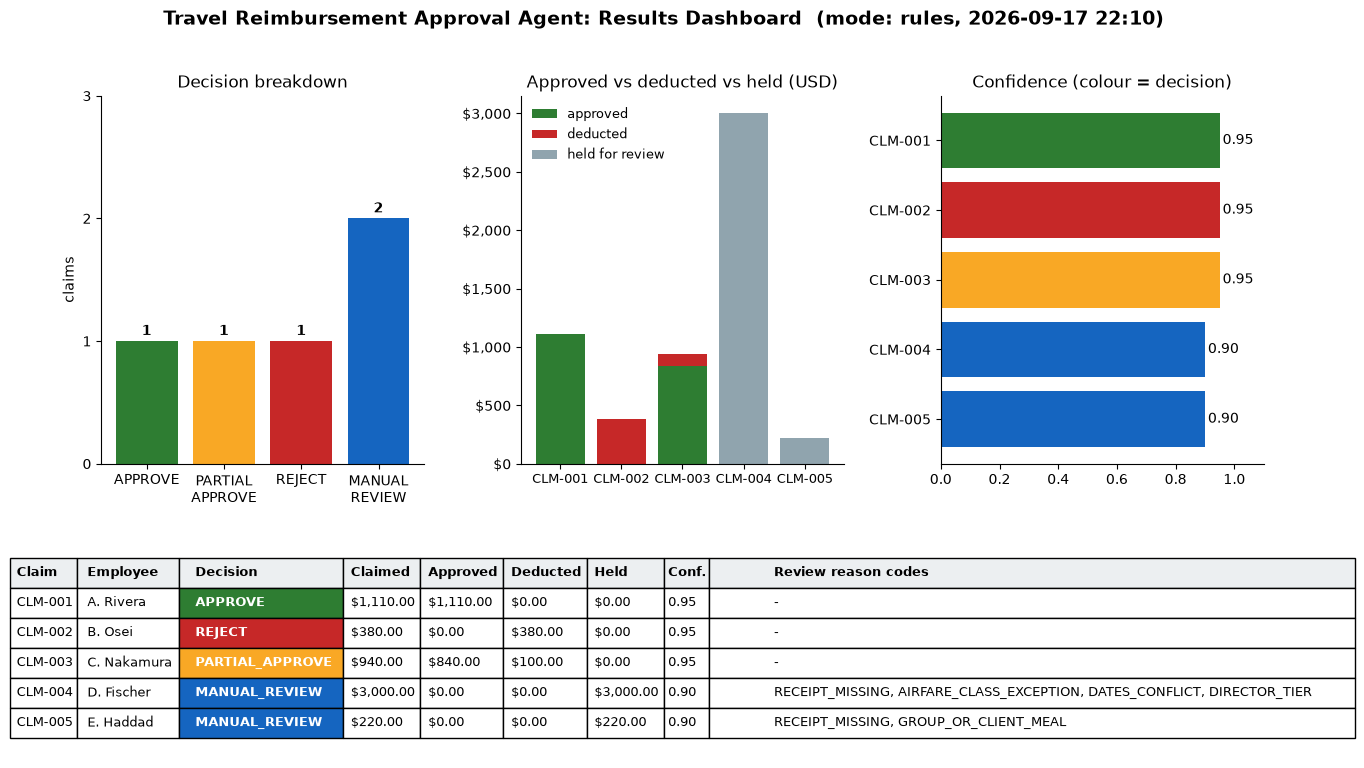

Review queue (claims that need a human):


,claim_id,employee,held,reason_codes,missing_docs
3,CLM-004,D. Fischer,3000.0,"RECEIPT_MISSING, AIRFARE_CLASS_EXCEPTION, DATE...","[Itemized receipt: Hotel, 3 nights ($600.00), ..."
4,CLM-005,E. Haddad,220.0,"RECEIPT_MISSING, GROUP_OR_CLIENT_MEAL",[Itemized receipt: Client dinner for 4 (busine...


In [28]:
import html

COLORS = {"APPROVE": "#2e7d32", "PARTIAL_APPROVE": "#f9a825", "REJECT": "#c62828", "MANUAL_REVIEW": "#1565c0"}
dash = pd.DataFrame([{**r, "employee": CLAIM_STORE[r["claim_id"]]["employee"],
                      "claimed": CLAIM_STORE[r["claim_id"]]["total_claimed"],
                      "held": AUDITS[r["claim_id"]].held_amount,
                      "reason_codes": ", ".join(AUDITS[r["claim_id"]].reason_codes) or "-",
                      "source": AUDITS[r["claim_id"]].source} for r in RESULTS])
tot = dash[["claimed", "approved_amount", "deducted_amount", "held"]].sum()
kpis = [("Claims", f"{len(dash)}"), ("Claimed", f"${tot.claimed:,.2f}"), ("Approved", f"${tot.approved_amount:,.2f}"),
        ("Deducted", f"${tot.deducted_amount:,.2f}"), ("Held for review", f"${tot.held:,.2f}"),
        ("Decided without a human", f"{(dash.decision != 'MANUAL_REVIEW').mean():.0%}")]
display(HTML("<div style='display:flex;gap:10px;flex-wrap:wrap;font-family:sans-serif'>" + "".join(
    f"<div style='border:1px solid #ccc;border-radius:8px;padding:8px 14px;min-width:120px'>"
    f"<div style='font-size:12px;color:#666'>{k}</div><div style='font-size:20px;font-weight:600'>{v}</div></div>"
    for k, v in kpis) + "</div>"))

fig = plt.figure(figsize=(15, 8.6))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.6], hspace=0.25, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
counts = dash.decision.value_counts().reindex(DECISIONS, fill_value=0)
ax1.bar([d.replace("_", "\n") for d in DECISIONS], counts.values, color=[COLORS[d] for d in DECISIONS])
for i, v in enumerate(counts.values):
    ax1.text(i, v + 0.05, str(v), ha="center", fontweight="bold")
ax1.set(title="Decision breakdown", ylabel="claims", ylim=(0, counts.max() + 1))
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax2 = fig.add_subplot(gs[0, 1])
xs = list(range(len(dash)))
ax2.bar(xs, dash.approved_amount, color="#2e7d32", label="approved")
ax2.bar(xs, dash.deducted_amount, bottom=dash.approved_amount, color="#c62828", label="deducted")
ax2.bar(xs, dash.held, bottom=dash.approved_amount + dash.deducted_amount, color="#90a4ae", label="held for review")
ax2.set_xticks(xs, dash.claim_id, fontsize=9)
ax2.yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
ax2.set_title("Approved vs deducted vs held (USD)")
ax2.legend(frameon=False, fontsize=9)

ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(dash.claim_id, dash.confidence, color=[COLORS[d] for d in dash.decision])
for i, v in enumerate(dash.confidence):
    ax3.text(v + 0.01, i, f"{v:.2f}", va="center")
ax3.set(xlim=(0, 1.1), title="Confidence (colour = decision)")
ax3.invert_yaxis()
for ax in (ax1, ax2, ax3):
    ax.spines[["top", "right"]].set_visible(False)

ax4 = fig.add_subplot(gs[1, :])
ax4.axis("off")
cols = ["Claim", "Employee", "Decision", "Claimed", "Approved", "Deducted", "Held", "Conf.", "Review reason codes"]
rows = [[r.claim_id, r.employee, r.decision, f"${r.claimed:,.2f}", f"${r.approved_amount:,.2f}",
         f"${r.deducted_amount:,.2f}", f"${r.held:,.2f}", f"{r.confidence:.2f}", r.reason_codes] for r in dash.itertuples()]
tbl = ax4.table(cellText=rows, colLabels=cols, loc="center", cellLoc="left", colLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.8)
tbl.auto_set_column_width(list(range(len(cols))))
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")
        cell.set_facecolor("#eceff1")
    elif col == 2:
        cell.set_text_props(color="white", fontweight="bold")
        cell.set_facecolor(COLORS[rows[row - 1][2]])
fig.suptitle(f"Travel Reimbursement Approval Agent: Results Dashboard  (mode: {RUN_MODE}, {datetime.now():%Y-%m-%d %H:%M})",
             fontsize=14, fontweight="bold")
fig.savefig("UI SS_1.png", dpi=150, bbox_inches="tight")
plt.show()

print("Review queue (claims that need a human):")
display(dash[dash.decision == "MANUAL_REVIEW"][["claim_id", "employee", "held", "reason_codes", "missing_docs"]])

In [29]:
def result_card_html(r, audit):
    """HTML card for one result: decision badge, amounts, explanation, refs, and a collapsible audit trail."""
    color = COLORS[r["decision"]]
    calls = audit.frame()
    calls = calls[calls.event.isin(["tool_call", "validation", "reconcile", "fallback", "llm_error"])] if len(calls) else calls
    keep = [c for c in ["time", "event", "caller", "tool", "flags", "result", "error", "final"] if c in calls.columns]
    return f"""
<div style="border:1px solid #ddd;border-left:6px solid {color};border-radius:6px;padding:10px 14px;margin:8px 0;font-family:sans-serif">
  <div><b>{r['claim_id']}</b> &nbsp;
    <span style="background:{color};color:#fff;padding:2px 9px;border-radius:10px;font-size:12px">{r['decision']}</span>
    &nbsp; approved <b>${r['approved_amount']:,.2f}</b> · deducted <b>${r['deducted_amount']:,.2f}</b>
    · held ${audit.held_amount:,.2f} · confidence <b>{r['confidence']:.2f}</b> · <i>{html.escape(audit.source or '')}</i></div>
  <p style="margin:8px 0">{html.escape(r['explanation'])}</p>
  <div style="font-size:13px"><b>Missing docs:</b> {html.escape('; '.join(r['missing_docs']) or 'none')}<br>
    <b>Policy refs:</b> {', '.join(r['policy_refs'])}<br><b>Tools used:</b> {', '.join(r['tools_used'])}</div>
  <details style="margin-top:6px"><summary>Audit trail ({len(audit.events)} events)</summary>
    {calls[keep].to_html(index=False) if len(calls) else ''}</details>
</div>"""


try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

if widgets is None:
    print("ipywidgets not installed: the interactive console is unavailable. Use review_claim(<dict or JSON>).")
else:
    pick = widgets.Dropdown(options=[c["claim_id"] for c in SAMPLE_CLAIMS], description="Claim:")
    mode_toggle = widgets.ToggleButtons(options=[("LLM agent", "llm"), ("Rules only", "rules")], value=RUN_MODE,
                                        description="Mode:")
    run_btn = widgets.Button(description="Evaluate claim", button_style="primary", icon="play")
    editor = widgets.Textarea(value=json.dumps(SAMPLE_CLAIMS[0], indent=2),
                              layout=widgets.Layout(width="98%", height="260px"))
    submit_btn = widgets.Button(description="Submit JSON claim", button_style="info", icon="upload")
    console_out = widgets.Output()

    def _render(job):
        with console_out:
            console_out.clear_output()
            try:
                display(HTML(result_card_html(*job())))
            except Exception as exc:
                print(f"{type(exc).__name__}: {exc}")

    run_btn.on_click(lambda _: _render(lambda: process_claim(pick.value, mode_toggle.value)))
    submit_btn.on_click(lambda _: _render(lambda: review_claim(editor.value, mode_toggle.value)))
    display(widgets.VBox([widgets.HTML("<h3>Claim review console</h3>"), widgets.HBox([pick, run_btn]), mode_toggle,
                          widgets.HTML("<b>Or submit a claim as JSON (form input / API body). Change the claim_id to add a new claim:</b>"),
                          editor, submit_btn, console_out]))

display(HTML("<h3>Result cards (static snapshot)</h3>"))
for r in RESULTS:
    display(HTML(result_card_html(r, AUDITS[r["claim_id"]])))

time,event,caller,tool,flags,result,error,final
22:10:35.611,tool_call,planner,check_category_eligibility,,,,
22:10:35.611,tool_call,planner,check_receipts,,,,
22:10:35.611,tool_call,planner,check_per_diem_limits,,,,
22:10:35.611,tool_call,planner,check_submission_timeliness,,,,
22:10:35.611,tool_call,planner,check_approval_threshold,,,,
22:10:35.611,tool_call,planner,search_policy,,,,
22:10:35.611,validation,,submit_decision,,accepted,,
22:10:35.611,reconcile,,,,agreed,,APPROVE


time,event,caller,tool,flags,result,error,final
22:10:35.612,tool_call,planner,check_category_eligibility,,,,
22:10:35.612,tool_call,planner,search_policy,,,,
22:10:35.612,validation,,submit_decision,,accepted,,
22:10:35.612,reconcile,,,,agreed,,REJECT


time,event,caller,tool,flags,result,error,final
22:10:35.612,tool_call,planner,check_category_eligibility,,,,
22:10:35.612,tool_call,planner,check_receipts,,,,
22:10:35.612,tool_call,planner,check_per_diem_limits,,,,
22:10:35.612,tool_call,planner,check_submission_timeliness,,,,
22:10:35.612,tool_call,planner,check_approval_threshold,,,,
22:10:35.612,tool_call,planner,search_policy,,,,
22:10:35.613,validation,,submit_decision,,accepted,,
22:10:35.613,reconcile,,,,agreed,,PARTIAL_APPROVE


time,event,caller,tool,flags,result,error,final
22:10:35.613,tool_call,planner,check_category_eligibility,,,,
22:10:35.613,tool_call,planner,check_receipts,RECEIPT_MISSING,,,
22:10:35.613,tool_call,planner,check_per_diem_limits,"AIRFARE_CLASS_EXCEPTION, DATES_CONFLICT",,,
22:10:35.613,tool_call,planner,check_submission_timeliness,,,,
22:10:35.613,tool_call,planner,check_approval_threshold,DIRECTOR_TIER,,,
22:10:35.613,tool_call,planner,search_policy,,,,
22:10:35.613,validation,,submit_decision,,accepted,,
22:10:35.613,reconcile,,,,agreed,,MANUAL_REVIEW


time,event,caller,tool,flags,result,error,final
22:10:35.613,tool_call,planner,check_category_eligibility,,,,
22:10:35.613,tool_call,planner,check_receipts,RECEIPT_MISSING,,,
22:10:35.613,tool_call,planner,check_per_diem_limits,GROUP_OR_CLIENT_MEAL,,,
22:10:35.613,tool_call,planner,check_submission_timeliness,,,,
22:10:35.614,tool_call,planner,check_approval_threshold,,,,
22:10:35.614,tool_call,planner,search_policy,,,,
22:10:35.614,validation,,submit_decision,,accepted,,
22:10:35.614,reconcile,,,,agreed,,MANUAL_REVIEW


## Design Notes & Reasoning

### Results
| Claim | Decision | Approved | Deducted | Why |
|---|---|---|---|---|
| CLM-001 | APPROVE | \$1,110.00 | \$0.00 | Everything is eligible and receipted. Lodging \$360 is under the \$400 cap and meals \$180 under the \$225 cap. Total is in the manager tier (POL-APR-02). |
| CLM-002 | REJECT | \$0.00 | \$380.00 | Spa and minibar are both POL-CAT-02, and no business purpose is stated. |
| CLM-003 | PARTIAL_APPROVE | \$840.00 | \$100.00 | Lodging \$500 is over the \$400 cap for 2 nights (POL-PD-02). Meals \$140 are under the \$150 cap. |
| CLM-004 | MANUAL_REVIEW | \$0.00 | \$0.00 | Four independent triggers (see below). |
| CLM-005 | MANUAL_REVIEW | \$0.00 | \$0.00 | The \$220 receipt is missing, and it is a hosted client meal (see below). |

### Why these cases go to manual review
- **CLM-004** has four triggers:
  - Business-class airfare is a policy exception that may be pre-approved, so it must not be auto-deducted (POL-AIR-01).
  - The lodging receipt is missing (POL-RCT-02).
  - The \$3,000 total exceeds the agent's \$2,000 authority (POL-APR-03).
  - **Conflicting data:** 3 hotel nights are claimed on a 16–18 June trip, which spans 2 nights. At 3 nights, lodging is exactly at the cap. At 2 nights, it is \$200 over. Only the missing receipt can settle this, so the agent flags it instead of guessing.
- **CLM-005** has a missing receipt for a \$220 item (POL-RCT-02). Beyond that, it is a *client dinner for 4*. The \$75/day meal cap is written for a traveller's own meals, and the policy has no rule for hosting clients. Auto-deducting \$145 could be wrong, so the agent reports that figure as the strict-cap outcome and leaves the call to a reviewer.
- More generally, the policy says to *prefer manual review over forcing a decision*. Any tool flag, whether mandated by policy or a detected ambiguity, therefore routes the claim to a human, together with reason codes and a list of missing documents.

### Assumptions
1. **Expense date = trip start date.** Line items carry no dates, and the earliest possible date is the strictest reading of POL-TIME-01.
2. **Nights and days are read from the item description.** If the description doesn't say, they are derived from the trip dates (nights = end − start; days counted inclusively). Caps apply to the claimed quantity.
3. **Manual-review amounts.** `approved_amount = 0`, because the agent has no approval authority. `deducted_amount` includes only certain deductions (POL-CAT-02 items). The rest is shown as *held for review* on the dashboard.
4. **The tier total includes held amounts.** The approval tier is computed on the reimbursable total after caps. That total includes business-class fares (not auto-deducted, per POL-AIR-01) and items missing receipts (not silently rejected, per POL-RCT-02).
5. **Confidence is computed, not self-reported by the LLM**, because model self-confidence is poorly calibrated. The formula:
   - start at 0.95;
   - subtract 0.05 for each ambiguity flag;
   - subtract 0.10 if the guardrail overrode the LLM;
   - use 0.75 for an escalation that only the LLM identified.

   It measures confidence that the *routing* is correct, not the likelihood of payout.

### Trade-offs
- **Direct OpenAI-compatible tool calling instead of LangChain/LangGraph.** There are six tools and one loop, so a framework would add dependencies and abstraction without adding capability. The same code runs on Groq, Gemini, Ollama or OpenAI. LangGraph becomes worthwhile once there is human-in-the-loop state, such as a reviewer requesting a receipt and the claim resuming afterwards.
- **BM25 over 12 rules instead of embeddings and a vector database.** It is exact, deterministic and dependency-free, and rule ids resolve directly. A real multi-page policy would call for embeddings plus a reranker.
- **The LLM orchestrates and explains; code does the arithmetic and hard rules.** The guardrail lets the LLM *escalate* but never *downgrade*. The cost is that the LLM cannot "creatively" approve an exception, which is intended.
- **Rules fallback.** The notebook runs without a key and survives rate limits or tool-calling errors. The audit trail records which path produced each result.
- **Heuristic flags** (cabin class, group meals, ineligible terms in descriptions) err toward manual review. False positives cost reviewer time; false negatives cost money.
- **Floats rounded to cents** are fine at this scale; production code would use `Decimal`.

### Known gaps and limitations
- Receipts are not parsed (no OCR, no amount or vendor matching); `receipt_attached` is trusted as given.
- Line items are totals, not per-day entries, so caps apply to the total. A single over-cap day hidden inside a within-cap total would not be caught.
- There is no duplicate detection across claims or employees, since the batch is a single set.
- Keyword heuristics can miss paraphrases. The LLM layer partly covers this through escalation.
- Free-tier rate limits mean claims run one after another with a short pause.
- There is no authentication, persistence or PII handling; this is a prototype.

### What I would improve next
1. Receipt OCR, then reconcile each receipt's amount, date and vendor against its line item.
2. A LangGraph workflow with `interrupt()` for human-in-the-loop review, so a reviewer's action resumes the claim.
3. Expose the tools through an MCP server, so the same checks can serve this agent, a chatbot and an ERP workflow.
4. A labelled evaluation set of 50+ claims, including adversarial descriptions, tracked for every model or prompt change and used to calibrate confidence.
5. Duplicate detection (same employee, date, amount and vendor) and per-day line items.
6. Policy versioning, with the version stamped on every decision for audit.

## Final structured results
A JSON array with one object per claim, containing exactly the fields `claim_id`, `decision`, `approved_amount`, `deducted_amount`, `missing_docs`, `policy_refs`, `confidence`, `explanation` and `tools_used`.

In [30]:
final_output = [validate_result(dict(r)) for r in RESULTS]
print(json.dumps(final_output, indent=2))

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-AIR-01",
      "POL-RCT-01",
      "POL-APR-02",
      "POL-TIME-01"
    ],
    "confidence": 0.95,
    "explanation": "All 4 items are eligible business expenses (POL-CAT-01) with receipts attached (POL-RCT-01), airfare is economy (POL-AIR-01), and amounts are within the caps (lodging $360.00 vs cap $400.00; meals $180.00 vs cap $225.00). It was submitted 10 days after travel (POL-TIME-01). The reimbursable total $1,110.00 falls in the manager tier (POL-APR-02), so the full amount is approved.",
    "tools_used": [
      "check_category_eligibility",
      "check_receipts",
      "check_per_diem_limits",
      "check_submission_timeliness",
      "check_approval_threshold",
      "search_policy",
      "submit_decision"
    ]
  },
  {
    "claim_id": "CLM-